# Metropolis algorithm with importance sampling  

## Analytic local energy

Results for N = 1, d = 3:
Minimum energy: 1.47
Minimum alpha: 0.56

Results for N = 10, d = 3:
Minimum energy: 14.99
Minimum alpha: 0.56

Results for N = 100, d = 3:
Minimum energy: 149.02
Minimum alpha: 0.40

Results for N = 500, d = 3:
Minimum energy: 465.29
Minimum alpha: 0.16



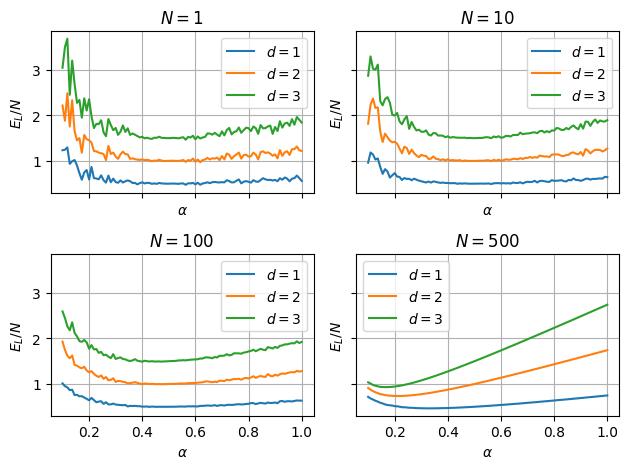

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

from vmc_jax import MetropolisJAX
from bose_harmonic import HarmonicParamGrid
from bose_harmonic_jax import (
  wavefunction_jax,
  local_energy_jax,
  drift_force_jax,
  HarmonicParams,
)

cycles = 10_000
base_dt = 0.01
diffusion_coefficient = 0.5

alpha_values = np.linspace(0.1, 1.0, 100)
param_grid = HarmonicParamGrid(param_type=HarmonicParams, alpha=alpha_values)

number_particles = [1, 10, 100, 500]
dims = [1, 2, 3]

fig, axs = plt.subplots(2, 2, sharex=True, sharey=True)
axs = axs.ravel()

for i, n in enumerate(number_particles):
  ax = axs[i]

  for j, d in enumerate(dims):
    time_step = base_dt / np.sqrt(n)

    simulation = MetropolisJAX[HarmonicParams](n, d)
    result = simulation.grid_search_importance(
      wavefunction_jax,
      local_energy_jax,
      drift_force_jax,
      param_grid,
      time_step,
      diffusion_coefficient,
      cycles,
    )

    energies = result.energy
    ax.plot(alpha_values, energies / n, label=f"$d = {d}$")
    ax.set_title(f"$N = {n}$")
    ax.set(xlabel=r"$\alpha$", ylabel=r"$E_L /N$")
    ax.legend()
    ax.grid(True)

    if d == 3:
      min_energy = np.min(energies)
      min_alpha = alpha_values[np.argmin(energies)]
      print(f"Results for N = {n}, d = {d}:")
      print(f"Minimum energy: {min_energy:.2f}")
      print(f"Minimum alpha: {min_alpha:.2f}\n")

plt.tight_layout()
plt.show()


## Numerical local energy

Results for N = 1, d = 3:
Minimum energy: 1.50
Minimum alpha: 0.54

Results for N = 10, d = 3:
Minimum energy: 14.66
Minimum alpha: 0.46

Results for N = 3, d = 3:
Minimum energy: 4.47
Minimum alpha: 0.53

Results for N = 4, d = 3:
Minimum energy: 5.96
Minimum alpha: 0.53



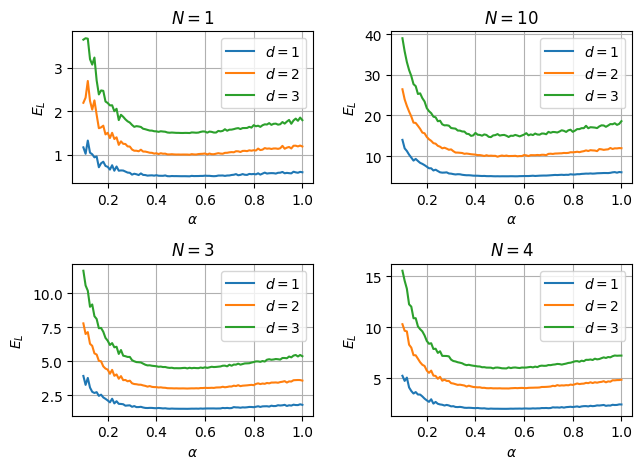

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

from vmc_jax import MetropolisJAX
from bose_harmonic import HarmonicParamGrid
from bose_harmonic_jax import (
  wavefunction_jax,
  local_energy_numeric_jax,
  drift_force_numeric_jax,
  HarmonicParams,
)

cycles = 10_000
time_step = 0.05
diffusion_coefficient = 0.5

alpha_values = np.linspace(0.1, 1.0, 100)
param_grid = HarmonicParamGrid(param_type=HarmonicParams, alpha=alpha_values)

number_particles = [1, 10, 3, 4]
dims = [1, 2, 3]

fig, axs = plt.subplots(2, 2)
axs = axs.ravel()

for i, n in enumerate(number_particles):
  ax = axs[i]

  for j, d in enumerate(dims):
    simulation = MetropolisJAX[HarmonicParams](n, d)
    results = simulation.grid_search_importance(
      wavefunction_jax,
      local_energy_numeric_jax,
      drift_force_numeric_jax,
      param_grid,
      time_step,
      diffusion_coefficient,
      cycles,
    )
    energies = results.energy
    ax.plot(alpha_values, energies, label=f"$d = {d}$")
    ax.set_title(f"$N = {n}$")
    ax.set(xlabel=r"$\alpha$", ylabel=r"$E_L$")
    ax.legend()
    ax.grid(True)

    if d == 3:
      min_energy = np.min(energies)
      min_alpha = alpha_values[np.argmin(energies)]
      print(f"Results for N = {n}, d = {d}:")
      print(f"Minimum energy: {min_energy:.2f}")
      print(f"Minimum alpha: {min_alpha:.2f}\n")

plt.tight_layout()
plt.show()

## Comparison of analytic and numeric approach

Analytic time: 3.81 s
Numeric time: 185.82 s
Analytic is 48.82x faster


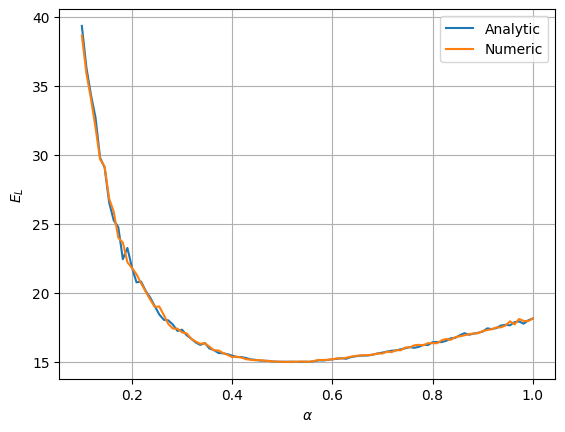

In [ ]:
import time

from matplotlib import pyplot as plt
import numpy as np

from vmc import Metropolis
from bose_harmonic import (
  wavefunction,
  local_energy,
  drift_force,
  drift_force_numeric,
  local_energy_numeric,
  HarmonicParams,
  HarmonicParamGrid,
)

cycles = 10_000
time_step = 0.05
diffusion_coefficient = 0.5

alpha_values = np.linspace(0.1, 1.0, 100)
param_grid = HarmonicParamGrid(param_type=HarmonicParams, alpha=alpha_values)

number_particles = 10
dim = 3

# Analytic
simulation = Metropolis[HarmonicParams](number_particles, dim)

start_analytic = time.perf_counter()
result_analytic = simulation.grid_search_importance(
  wavefunction,
  local_energy,
  drift_force,
  param_grid,
  time_step,
  diffusion_coefficient,
  cycles,
)
stop_analytic = time.perf_counter()
time_analytic = stop_analytic - start_analytic

# Numeric
simulation_numeric = Metropolis[HarmonicParams](number_particles, dim)
start_numeric = time.perf_counter()
result_numeric = simulation.grid_search_importance(
  wavefunction,
  local_energy_numeric,
  drift_force_numeric,
  param_grid,
  time_step,
  diffusion_coefficient,
  cycles,
)
stop_numeric = time.perf_counter()
time_numeric = stop_numeric - start_numeric

print(f"Analytic time: {time_analytic:.2f} s")
print(f"Numeric time: {time_numeric:.2f} s")
if time_analytic < time_numeric:
  factor = time_numeric / time_analytic
  print(f"Analytic is {factor:.2f}x faster")
else:
  factor = time_analytic / time_numeric
  print(f"Numeric is {factor:.2f}x faster")

plt.plot(alpha_values, result_analytic.energy, label="Analytic")
plt.plot(alpha_values, result_numeric.energy, label="Numeric")
plt.xlabel(r"$\alpha$")
plt.ylabel(r"$E_L$")
plt.legend()
plt.grid(True)
plt.show()

### Comparison of brute force and importance sampling Metropolis algorith 

Importance time: 96.08 s
Brute force time: 48.58 s
Brute force sampling is 1.98x faster


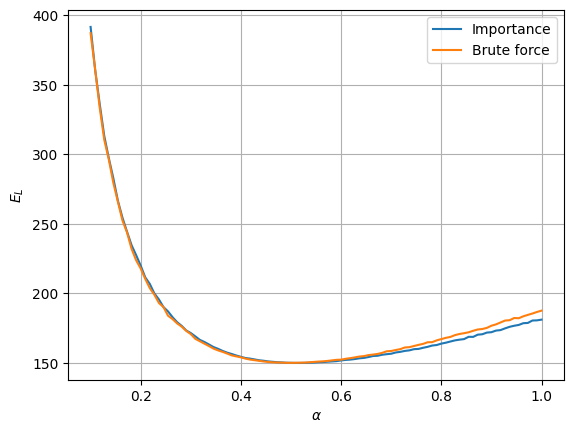

In [5]:
import time

from matplotlib import pyplot as plt
import numpy as np

from vmc import Metropolis
from bose_harmonic import (
  wavefunction,
  local_energy,
  drift_force,
  HarmonicParams,
  HarmonicParamGrid,
)

cycles = 10_000
step_size = 1.0
time_step = 0.05
diffusion_coefficient = 0.5

alpha_values = np.linspace(0.1, 1.0, 100)
param_grid = HarmonicParamGrid(param_type=HarmonicParams, alpha=alpha_values)

number_particles = 100
dimension = 3

simulation = Metropolis[HarmonicParams, HarmonicParamGrid](number_particles, dimension)

start_importance = time.perf_counter()
results_importance = simulation.grid_search_importance(
  wavefunction,
  local_energy,
  drift_force,
  param_grid,
  time_step,
  diffusion_coefficient,
  cycles,
)
end_importance = time.perf_counter()
time_importance = end_importance - start_importance

start_brute = time.perf_counter()
results_brute = simulation.grid_search(
  wavefunction,
  local_energy,
  param_grid,
  step_size,
  cycles,
)
end_brute = time.perf_counter()
time_brute = end_brute - start_brute

print(f"Importance time: {time_importance:.2f} s")
print(f"Brute force time: {time_brute:.2f} s")
if time_importance < time_brute:
  factor = time_brute / time_importance
  print(f"Importance sampling is {factor:.2f}x faster")
else:
  factor = time_importance / time_brute
  print(f"Brute force sampling is {factor:.2f}x faster")

energies_importance = [r["energy"] for r in results_importance]
energies_brute = [r["energy"] for r in results_brute]

plt.plot(alpha_values, energies_importance, label="Importance")
plt.plot(alpha_values, energies_brute, label="Brute force")
plt.xlabel(r"$\alpha$")
plt.ylabel(r"$E_L$")
plt.legend()
plt.grid(True)
plt.show()